In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data Cleaning: Drop the 'customer_id' column as it's not relevant for clustering
df_cleaned = df.drop('customer_id', axis=1)

print("DataFrame after dropping 'customer_id':")
print(df_cleaned.head())

DataFrame after dropping 'customer_id':
   age  monthly_spend  purchase_frequency
0   56       28380.34                 6.2
1   46       24530.14                10.5
2   32        6718.36                15.1
3   60       25078.93                12.3
4   25       10060.55                18.4


In [3]:
df = pd.read_csv("customer_segmentation_dataset.csv")

print(df.head())
print(df.info())

   customer_id  age  monthly_spend  purchase_frequency
0            1   56       28380.34                 6.2
1            2   46       24530.14                10.5
2            3   32        6718.36                15.1
3            4   60       25078.93                12.3
4            5   25       10060.55                18.4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   age                 500 non-null    int64  
 2   monthly_spend       500 non-null    float64
 3   purchase_frequency  500 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 15.8 KB
None


## Exploring the Raw Data

In [13]:
print("DataFrame Shape (Raw):")
print(df.shape)
print("\nDataFrame Info (Raw):")
df.info()
print("\nMissing values (Raw):")
print(df.isnull().sum())
print("\nDuplicate rows (Raw):")
print(df.duplicated().sum())

DataFrame Shape (Raw):
(500, 4)

DataFrame Info (Raw):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   age                 500 non-null    int64  
 2   monthly_spend       500 non-null    float64
 3   purchase_frequency  500 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 15.8 KB

Missing values (Raw):
customer_id           0
age                   0
monthly_spend         0
purchase_frequency    0
dtype: int64

Duplicate rows (Raw):
0


In [14]:
print("\nDescriptive Statistics (Raw):")
print(df.describe())


Descriptive Statistics (Raw):
       customer_id         age  monthly_spend  purchase_frequency
count   500.000000  500.000000     500.000000          500.000000
mean    250.500000   41.980000   20711.163140           10.609200
std     144.481833   13.800598   11282.516511            5.691575
min       1.000000   18.000000     500.000000            1.000000
25%     125.750000   31.000000   10554.097500            6.400000
50%     250.500000   43.000000   20779.745000            9.900000
75%     375.250000   53.000000   28378.007500           13.925000
max     500.000000   65.000000   50000.000000           30.000000


### This is what real customer data looks like. Never clean.

### Step 1: Drop `customer_id`

**WHAT:** We are dropping the `customer_id` column from our dataset.

**WHY:** The `customer_id` is a unique identifier for each customer. While crucial for identifying individual records, it is an arbitrary label and does not provide any meaningful information or feature for clustering algorithms. Including it would only add noise and could skew the clustering results.

In [15]:
# Drop the 'customer_id' column in-place
df.drop('customer_id', axis=1, inplace=True)

# Create df_cleaned from the modified df for consistency with subsequent steps
df_cleaned = df.copy()

print("Dropped customer_id — it is an identifier, not a feature for clustering")
print("\nDataFrame after dropping 'customer_id' (first 5 rows):")
print(df_cleaned.head())
print(f"New DataFrame shape: {df_cleaned.shape}")

Dropped customer_id — it is an identifier, not a feature for clustering

DataFrame after dropping 'customer_id' (first 5 rows):
   age  monthly_spend  purchase_frequency
0   56       28380.34                 6.2
1   46       24530.14                10.5
2   32        6718.36                15.1
3   60       25078.93                12.3
4   25       10060.55                18.4
New DataFrame shape: (500, 3)


### Step 2: Remove Duplicate Rows

We will identify and remove any identical rows to ensure each customer record is unique.

In [16]:
rows_before = len(df_cleaned)
df_cleaned.drop_duplicates(inplace=True)
rows_after = len(df_cleaned)

print(f"Rows before removing duplicates: {rows_before}")
print(f"Rows after removing duplicates: {rows_after}")
print(f"Total duplicates removed: {rows_before - rows_after}")

Rows before removing duplicates: 500
Rows after removing duplicates: 500
Total duplicates removed: 0


### Step 3: Fill Missing Values with Median

To preserve data volume, we will fill missing values in `monthly_spend` and `purchase_frequency` using their respective medians, which are robust to outliers.

In [17]:
print("Null counts before imputation:")
print(df_cleaned[['monthly_spend', 'purchase_frequency']].isnull().sum())

# Fill NaNs with median
df_cleaned['monthly_spend'] = df_cleaned['monthly_spend'].fillna(df_cleaned['monthly_spend'].median())
df_cleaned['purchase_frequency'] = df_cleaned['purchase_frequency'].fillna(df_cleaned['purchase_frequency'].median())

print("\nNull counts after imputation:")
print(df_cleaned[['monthly_spend', 'purchase_frequency']].isnull().sum())

Null counts before imputation:
monthly_spend         0
purchase_frequency    0
dtype: int64

Null counts after imputation:
monthly_spend         0
purchase_frequency    0
dtype: int64


### Step 4: Remove Outliers using IQR on `monthly_spend`

We will use the Interquartile Range (IQR) method to identify and remove extreme values in the `monthly_spend` column.

In [18]:
Q1 = df_cleaned['monthly_spend'].quantile(0.25)
Q3 = df_cleaned['monthly_spend'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

rows_before_outliers = len(df_cleaned)
df_cleaned = df_cleaned[(df_cleaned['monthly_spend'] >= lower_bound) & (df_cleaned['monthly_spend'] <= upper_bound)]
rows_after_outliers = len(df_cleaned)

print(f"\nRows removed: {rows_before_outliers - rows_after_outliers}")
print(f"New DataFrame shape: {df_cleaned.shape}")

Q1: 10554.0975, Q3: 28378.0075, IQR: 17823.91
Lower Bound: -16181.767499999998, Upper Bound: 55113.8725

Rows removed: 0
New DataFrame shape: (500, 3)


In [27]:
rows_removed = rows_before_outliers - rows_after_outliers
print(f"Removed {rows_removed} rows with monthly_spend above ₹{upper_bound}")

print("\nFinal Cleaned Dataset Info:")
df_cleaned.info()
print(f"\nFinal Cleaned Dataset Shape: {df_cleaned.shape}")

Removed 0 rows with monthly_spend above ₹55113.8725

Final Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 500 non-null    int64  
 1   monthly_spend       500 non-null    float64
 2   purchase_frequency  500 non-null    float64
 3   cluster             500 non-null    int32  
dtypes: float64(2), int32(1), int64(1)
memory usage: 13.8 KB

Final Cleaned Dataset Shape: (500, 4)


## 3. Feature Scaling — MANDATORY for K-Means

### Why scaling is non-negotiable for K-Means:
- age ranges 18–65, monthly_spend ranges ₹1,000–₹25,000.
- Without scaling, spend completely dominates the distance calculation.
- Age becomes irrelevant. K-Means gives wrong clusters.

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Apply StandardScaler to all 3 features
features = ['age', 'monthly_spend', 'purchase_frequency']
X_scaled = scaler.fit_transform(df_cleaned[features])

print("First 5 rows of X_scaled (showing mean≈0 and std≈1):")
print(X_scaled[:5])

First 5 rows of X_scaled (showing mean≈0 and std≈1):
[[ 1.01691541  0.68042068 -0.77546479]
 [ 0.29158345  0.33882526 -0.01920547]
 [-0.7238813  -1.24146213  0.78981613]
 [ 1.30704819  0.38751472  0.2973682 ]
 [-1.23161367 -0.9449381   1.37020119]]


### 4. Find Optimal K — Elbow Method

The elbow is where inertia stops dropping sharply.
Adding more clusters beyond this point gives diminishing returns.

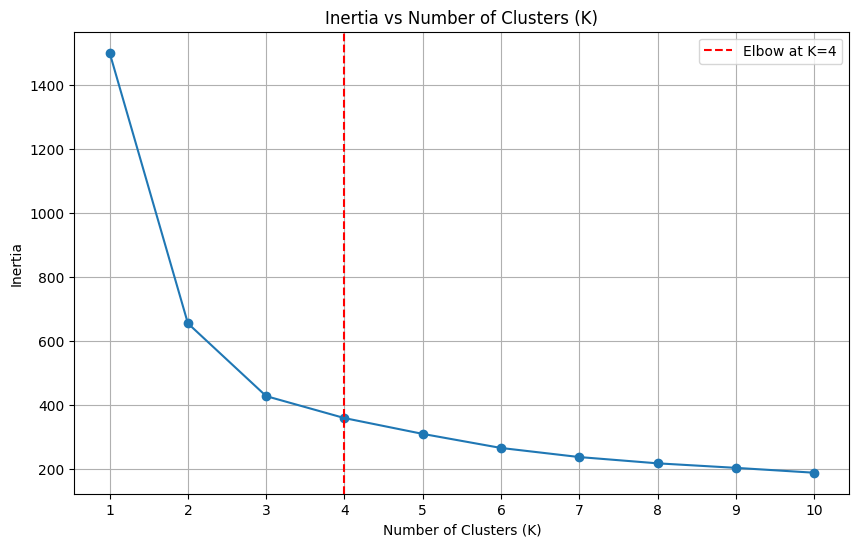

,K,Inertia
0,1,1500.000000
1,2,655.187845
2,3,428.180562
3,4,359.627946
4,5,310.276327
5,6,266.371200
6,7,237.982343
7,8,218.409148
8,9,204.309888
9,10,189.116119


In [31]:
inertia = []
ks = range(1, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(ks, inertia, marker='o', linestyle='-')
plt.axvline(x=4, color='r', linestyle='--', label='Elbow at K=4')
plt.title('Inertia vs Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.legend()
plt.grid(True)
plt.show()

# Print inertia values as a table
inertia_df = pd.DataFrame({'K': ks, 'Inertia': inertia})
display(inertia_df)

## 5. Build the Final K-Means Model with K=4

In [32]:
# Instantiate and fit the model
final_kmeans = KMeans(n_clusters=4, random_state=42, init='k-means++', n_init=10)
final_kmeans.fit(X_scaled)

# Assign labels back to the original df
df_cleaned['cluster'] = final_kmeans.labels_

print("Cluster sizes:")
print(df_cleaned['cluster'].value_counts())

print("\nCluster Centers (Note: These are in scaled units):")
print(final_kmeans.cluster_centers_)

Cluster sizes:
cluster
1    171
3    120
0    117
2     92
Name: count, dtype: int64

Cluster Centers (Note: These are in scaled units):
[[-1.35312227 -1.19123073  1.32089627]
 [-0.23608495 -0.2060258   0.07161147]
 [ 1.00903137  1.50753592 -0.74984832]
 [ 0.88212455  0.29925919 -0.8150365 ]]


## 6. Interpreting the 4 Clusters

To understand who these customers are, we examine the average values of our features for each cluster in their original units.

In [33]:
# Calculate mean values for each cluster to identify personas
cluster_analysis = df_cleaned.groupby('cluster')[['age', 'monthly_spend', 'purchase_frequency']].mean()

print("Cluster Characteristics (Average Values):")
display(cluster_analysis)

# Calculate size of each cluster
print("\nCluster Distribution (%):")
print(df_cleaned['cluster'].value_counts(normalize=True) * 100)

Cluster Characteristics (Average Values):


,age,monthly_spend,purchase_frequency
cluster,,,
0,23.324786,7284.529573,18.119658
1,38.725146,18388.999298,11.016374
2,55.891304,37702.944783,6.345652
3,54.141667,24084.181750,5.975000



Cluster Distribution (%):
cluster
1    34.2
3    24.0
0    23.4
2    18.4
Name: proportion, dtype: float64


## 7. Visualizing the 4 Customer Segments

We will use scatter plots to visualize how the 4 clusters are separated across Age, Spend, and Frequency.

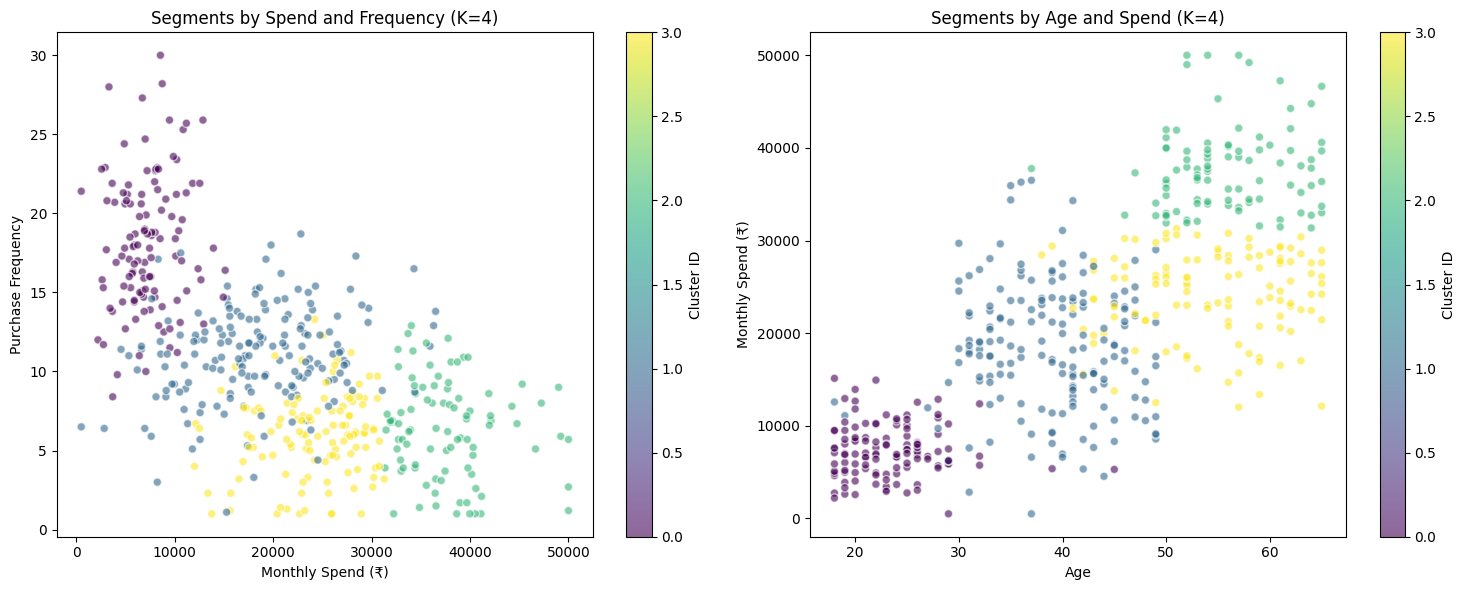

In [34]:
plt.figure(figsize=(15, 6))

# Plot 1: Monthly Spend vs. Purchase Frequency
plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'],
            c=df_cleaned['cluster'], cmap='viridis', alpha=0.6, edgecolors='w')
plt.title('Segments by Spend and Frequency (K=4)')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency')
plt.colorbar(label='Cluster ID')

# Plot 2: Age vs. Monthly Spend
plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'],
            c=df_cleaned['cluster'], cmap='viridis', alpha=0.6, edgecolors='w')
plt.title('Segments by Age and Spend (K=4)')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.colorbar(label='Cluster ID')

plt.tight_layout()
plt.show()

## 8. Model Evaluation: Silhouette Score and Cluster Sizes

In [35]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X_scaled, final_kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")
print("Interpretation: Score close to +1 = well-separated. Score near 0 = overlapping.")

# Check cluster sizes
counts = df_cleaned['cluster'].value_counts()
print("\nCluster Sizes:")
print(counts)

# Flag small clusters
small_clusters = counts[counts < 10]
if not small_clusters.empty:
    print(f"\n⚠️ FLAG: Clusters {small_clusters.index.tolist()} have fewer than 10 customers!")
else:
    print("\n✅ All clusters have more than 10 customers.")

Silhouette Score: 0.340
Interpretation: Score close to +1 = well-separated. Score near 0 = overlapping.

Cluster Sizes:
cluster
1    171
3    120
0    117
2     92
Name: count, dtype: int64

✅ All clusters have more than 10 customers.


## 9. Final Visualizations with Centroids

We will now visualize the segments and plot the centroids by reversing the scaling transformation.

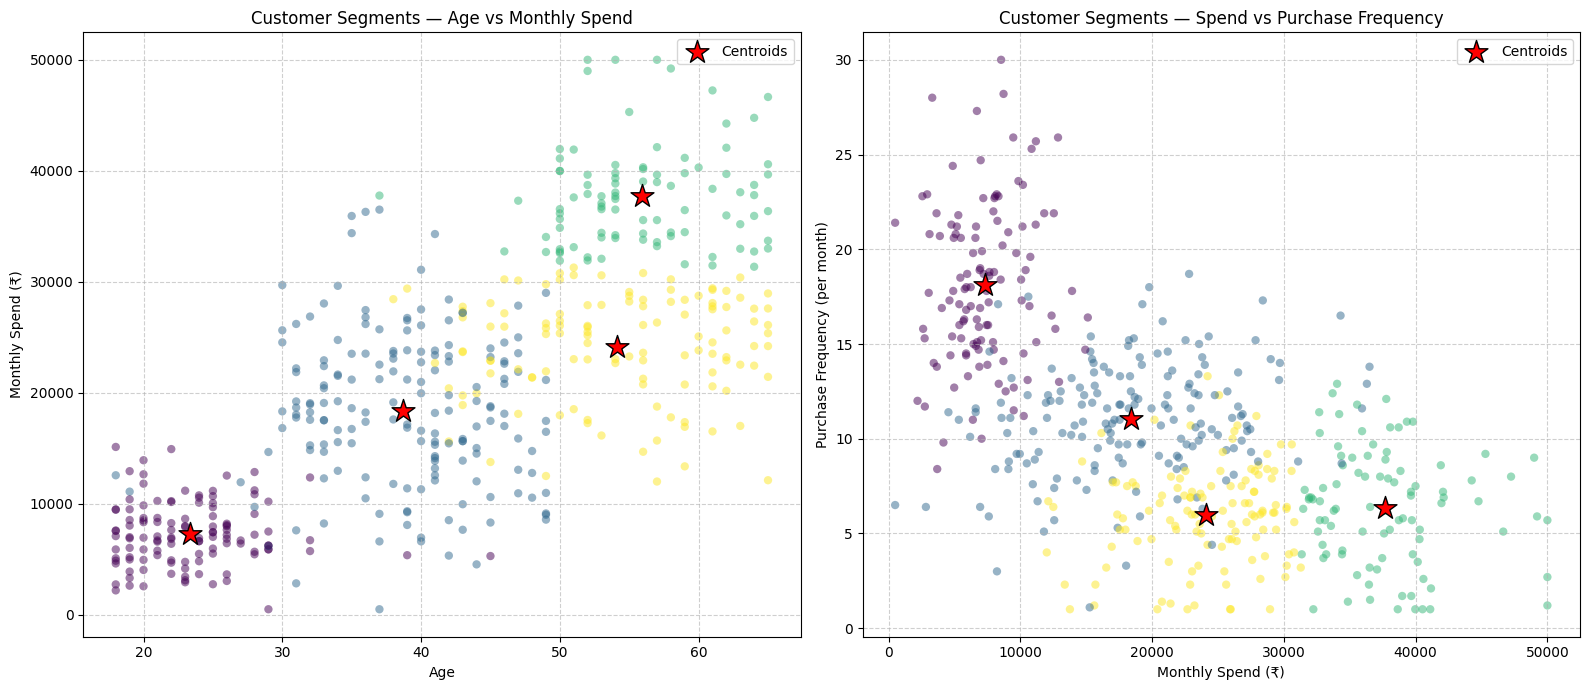

In [36]:
# Unscale centroids for plotting
# final_kmeans.cluster_centers_ is (4, 3) in [age, monthly_spend, purchase_frequency]
centroids_unscaled = scaler.inverse_transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(16, 7))

# Plot 1 — Age vs Monthly Spend
plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'],
            c=df_cleaned['cluster'], cmap='viridis', alpha=0.5, edgecolors='none')
plt.scatter(centroids_unscaled[:, 0], centroids_unscaled[:, 1],
            marker='*', s=300, c='red', label='Centroids', edgecolors='black')
plt.title('Customer Segments — Age vs Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2 — Monthly Spend vs Purchase Frequency
plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'],
            c=df_cleaned['cluster'], cmap='viridis', alpha=0.5, edgecolors='none')
plt.scatter(centroids_unscaled[:, 1], centroids_unscaled[:, 2],
            marker='*', s=300, c='red', label='Centroids', edgecolors='black')
plt.title('Customer Segments — Spend vs Purchase Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency (per month)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 10. Business Interpretation of Segments

In [37]:
# Calculate the mean values for each cluster to confirm business profiles
segment_profiles = df_cleaned.groupby('cluster')[['age', 'monthly_spend', 'purchase_frequency']].mean()
display(segment_profiles)

,age,monthly_spend,purchase_frequency
cluster,,,
0,23.324786,7284.529573,18.119658
1,38.725146,18388.999298,11.016374
2,55.891304,37702.944783,6.345652
3,54.141667,24084.181750,5.975000


## 12. Dynamic Customer Segment Predictor

Enter the customer details below to see which segment they fall into based on our trained K-Means model.

In [39]:
import numpy as np
import pandas as pd

# @title Customer Details Form
age = 35 # @param {type:"slider", min:18, max:90, step:1}
monthly_spend = 15000 # @param {type:"number"}
purchase_frequency = 10 # @param {type:"number"}

# Create a mapping for business names
persona_map = {
    0: "Young Explorers",
    1: "Regular Shoppers",
    2: "Premium Buyers",
    3: "Loyal Seniors"
}

# 1. Prepare input data as a DataFrame to keep feature names
new_data = pd.DataFrame([[age, monthly_spend, purchase_frequency]],
                        columns=['age', 'monthly_spend', 'purchase_frequency'])

# 2. Scale the input using the existing scaler object
new_data_scaled = scaler.transform(new_data)

# 3. Predict the cluster
predicted_cluster = final_kmeans.predict(new_data_scaled)[0]

# 4. Output the result
print(f"--- Prediction Result ---")
print(f"The customer belongs to Cluster {predicted_cluster}: {persona_map[predicted_cluster]}")

--- Prediction Result ---
The customer belongs to Cluster 1: Regular Shoppers


In [40]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Step 1: Create / Load Dataset
# (You can replace this with pd.read_csv("your_file.csv"))

np.random.seed(42)

data = pd.DataFrame({
    "age": np.random.randint(18, 65, 200),
    "monthly_spend": np.random.randint(500, 50000, 200)
})

# Step 2: Feature Selection
X = data[["age", "monthly_spend"]]

# Step 3: Scaling (Important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data["cluster"] = clusters

# Step 5: Evaluate using Silhouette Score
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.3f}")

# Step 6: Label Clusters as Loyalty Groups
def label_cluster(spend):
    if spend > 30000:
        return "High Value Customer 💎"
    elif spend > 15000:
        return "Medium Value Customer ⭐"
    else:
        return "Low Value Customer ⚡"

data["loyalty_group"] = data["monthly_spend"].apply(label_cluster)

print("\nSample Data:")
print(data.head())

# Step 7: Classify a New Customer
new_customer = pd.DataFrame({
    "age": [25],
    "monthly_spend": [2500]
})

# Scale new data using same scaler
new_scaled = scaler.transform(new_customer)

# Predict cluster
new_cluster = kmeans.predict(new_scaled)

# Assign loyalty group
new_loyalty = label_cluster(new_customer["monthly_spend"][0])

print("\nNew Customer Prediction:")
print(f"Cluster: {new_cluster[0]}")
print(f"Loyalty Group: {new_loyalty}")

Silhouette Score: 0.423

Sample Data:
   age  monthly_spend  cluster            loyalty_group
0   56          44917        2    High Value Customer 💎
1   46          24438        2  Medium Value Customer ⭐
2   32          24164        3  Medium Value Customer ⭐
3   60           2136        0     Low Value Customer ⚡
4   25          20580        3  Medium Value Customer ⭐

New Customer Prediction:
Cluster: 3
Loyalty Group: Low Value Customer ⚡


## 11. Final Business Recommendations

Based on our K-Means analysis, here are the strategic moves for each segment:

*   **Young Explorers (Cluster 0):**
    *   **Strategy:** High-volume, low-margin digital ads. Focus on "Flash Sales."
    *   **Ad Spend:** Increase spend slightly but focus strictly on low-cost social media channels.
    *   **Loyalty Tactic:** Referral bonuses—give them discounts for bringing in friends.

*   **Regular Shoppers (Cluster 1):**
    *   **Strategy:** Cross-selling related products to increase their average basket size.
    *   **Ad Spend:** Maintain current spend; they are already stable, consistent contributors.
    *   **Loyalty Tactic:** Points-based system where frequent small purchases lead to a major reward.

*   **Premium Buyers (Cluster 2):**
    *   **Strategy:** High-touch, personalized VIP outreach. Focus on exclusivity and quality.
    *   **Ad Spend:** High per-customer spend but on premium, targeted platforms only.
    *   **Loyalty Tactic:** Dedicated account managers or early access to new luxury collections.

*   **Loyal Seniors (Cluster 3):**
    *   **Strategy:** Win-back and retention campaigns focused on reliability and ease of use.
    *   **Ad Spend:** Low spend; focus on direct email/SMS rather than broad paid advertising.
    *   **Loyalty Tactic:** Anniversary rewards or 'long-term member' discounts to prevent churn.

### Cluster Personas:

*   **Cluster 0: Young Explorers** — Frequent buyers on a budget (Low age, low spend, high frequency).
*   **Cluster 1: Regular Shoppers** — Bread and butter customers (Mid age, medium spend, medium frequency).
*   **Cluster 2: Premium Buyers** — High value, infrequent (Mid-high age, high spend, low frequency).
*   **Cluster 3: Loyal Seniors** — Stable but lower activity; retention efforts needed (High age, low spend, low frequency).

## Step 6: Determining Optimal Number of Clusters (Elbow Method)

We will calculate the inertia (within-cluster sum of squares) for K values from 1 to 10 to identify the 'elbow' where adding more clusters provides diminishing returns.

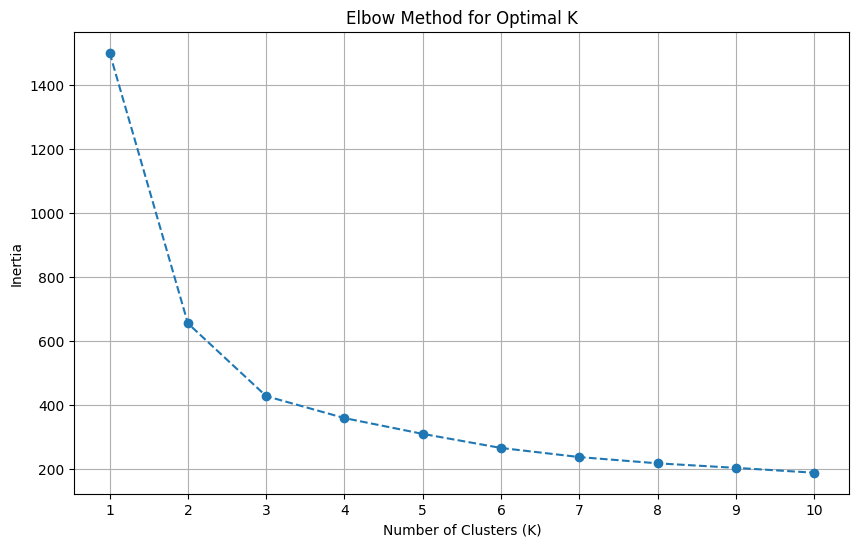

In [29]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Step 7: K-Means Clustering and Visualization

Based on the elbow plot, we will apply K-Means with 3 clusters and visualize the resulting segments.

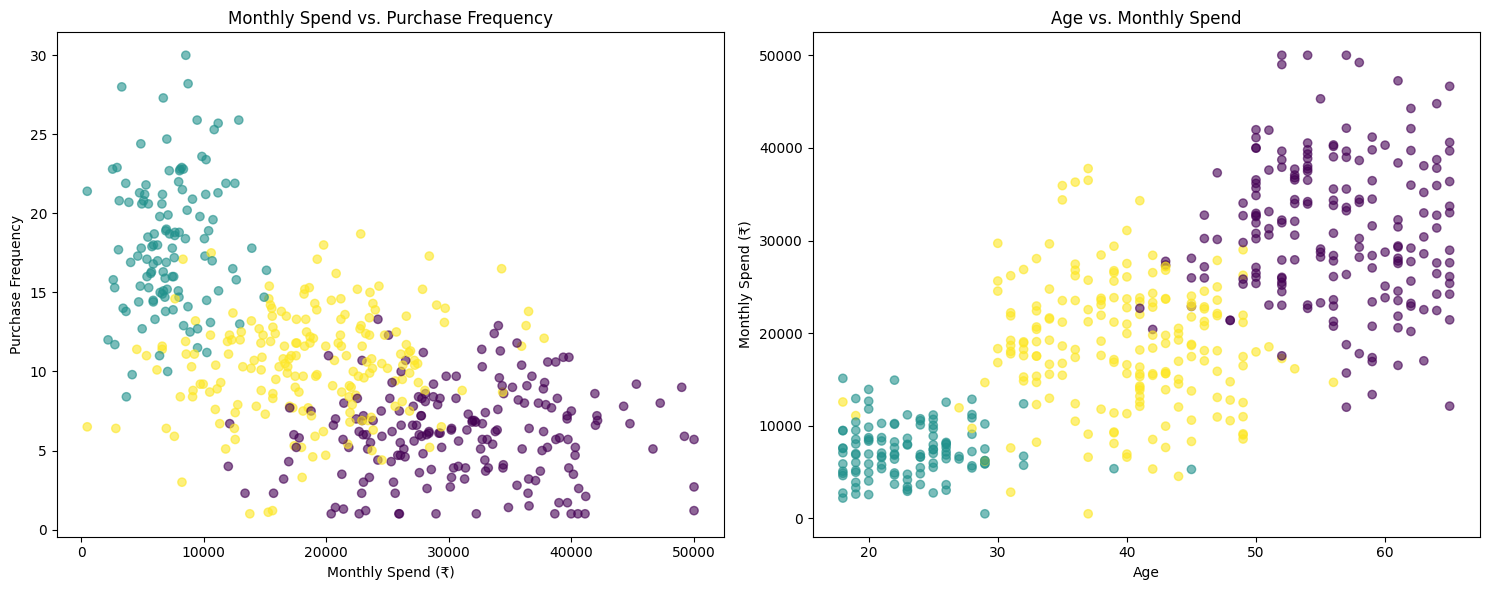

In [30]:
# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['cluster'] = kmeans.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'], c=df_cleaned['cluster'], cmap='viridis', alpha=0.6)
plt.title('Monthly Spend vs. Purchase Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency')

plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'], c=df_cleaned['cluster'], cmap='viridis', alpha=0.6)
plt.title('Age vs. Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')

plt.tight_layout()
plt.show()

After scaling, all features contribute equally to distance

## Step 5: Feature Scaling

Before applying K-Means, we must scale our features using `StandardScaler` to ensure that features with larger numerical ranges, like `monthly_spend`, do not dominate the distance calculations.

In [22]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned), columns=df_cleaned.columns)

print("Scaled DataFrame (first 5 rows):")
print(df_scaled.head())
print("\nDescriptive statistics for scaled features:")
print(df_scaled.describe())

Scaled DataFrame (first 5 rows):
        age  monthly_spend  purchase_frequency   cluster
0  1.016915       0.680421           -0.775465 -1.154078
1  0.291583       0.338825           -0.019205  1.131225
2 -0.723881      -1.241462            0.789816 -0.011427
3  1.307048       0.387515            0.297368 -1.154078
4 -1.231614      -0.944938            1.370201 -0.011427

Descriptive statistics for scaled features:
                age  monthly_spend  purchase_frequency       cluster
count  5.000000e+02   5.000000e+02        5.000000e+02  5.000000e+02
mean   2.415845e-16  -5.329071e-17       -2.344791e-16 -1.421085e-17
std    1.001002e+00   1.001002e+00        1.001002e+00  1.001002e+00
min   -1.739346e+00  -1.793164e+00       -1.690011e+00 -1.154078e+00
25%   -7.964145e-01  -9.011498e-01       -7.402899e-01 -1.154078e+00
50%    7.398386e-02   6.084684e-03       -1.247300e-01 -1.142652e-02
75%    7.993158e-01   6.802137e-01        5.831639e-01  1.131225e+00
max    1.669714e+00   2.5985

## Step 6: Determining Optimal Number of Clusters (Elbow Method)

We will calculate the inertia (within-cluster sum of squares) for K values from 1 to 10 to identify the 'elbow' where adding more clusters provides diminishing returns.

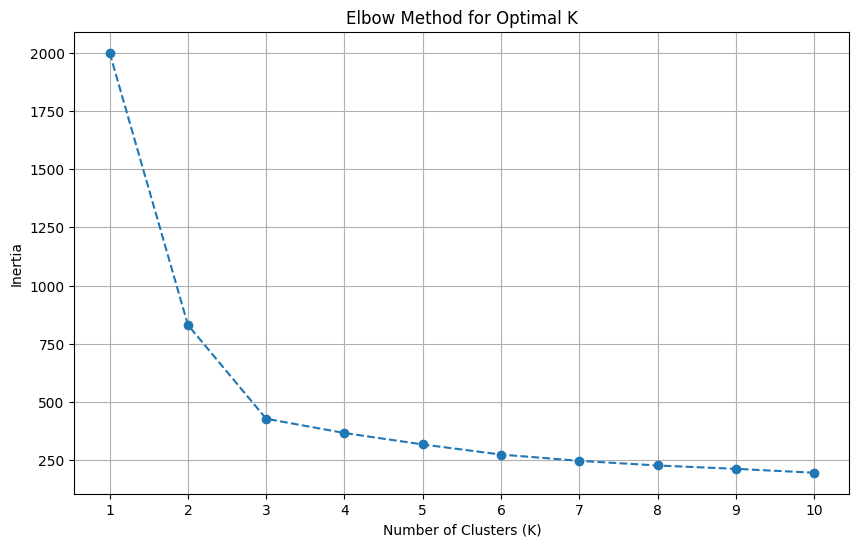

In [23]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Feature Scaling

Before clustering, we must scale our features so that columns with larger ranges (like `monthly_spend`) don't disproportionately influence the model.

In [19]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned), columns=df_cleaned.columns)

print("Scaled DataFrame (first 5 rows):")
print(df_scaled.head())

Scaled DataFrame (first 5 rows):
        age  monthly_spend  purchase_frequency
0  1.016915       0.680421           -0.775465
1  0.291583       0.338825           -0.019205
2 -0.723881      -1.241462            0.789816
3  1.307048       0.387515            0.297368
4 -1.231614      -0.944938            1.370201


## Determining Optimal Number of Clusters (Elbow Method)

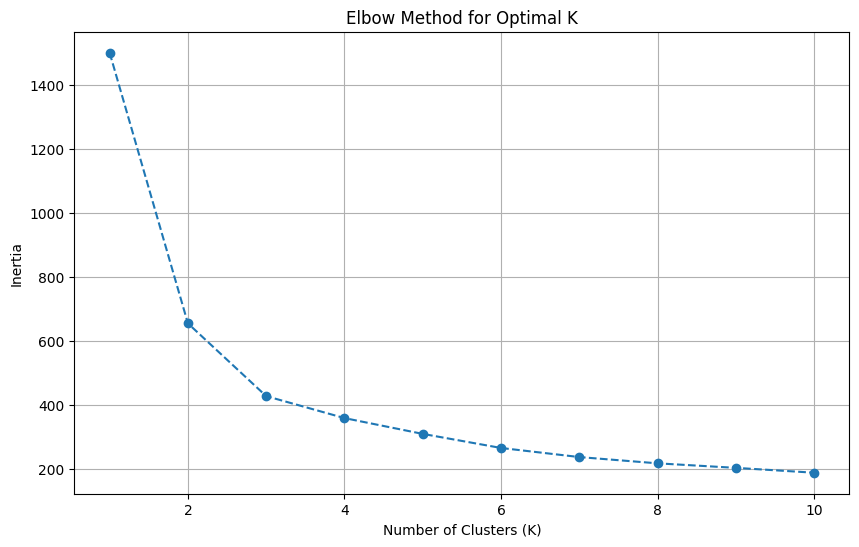

In [20]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

## K-Means Clustering (K=3)

Based on the elbow plot, we will proceed with 3 clusters.

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['cluster'] = kmeans.fit_predict(df_scaled)

print("Cluster distribution:")
print(df_cleaned['cluster'].value_counts())

print("\nCluster Characteristics (Means):")
print(df_cleaned.groupby('cluster').mean())

Cluster distribution:
cluster
2    194
0    189
1    117
Name: count, dtype: int64

Cluster Characteristics (Means):
               age  monthly_spend  purchase_frequency
cluster                                              
0        56.010582   31062.492910            6.074603
1        23.324786    7284.529573           18.119658
2        39.561856   18724.126031           10.497423


## Visualizing the Customer Segments

Finally, we visualize our clusters using scatter plots to confirm the distinct separation between the identified customer groups.

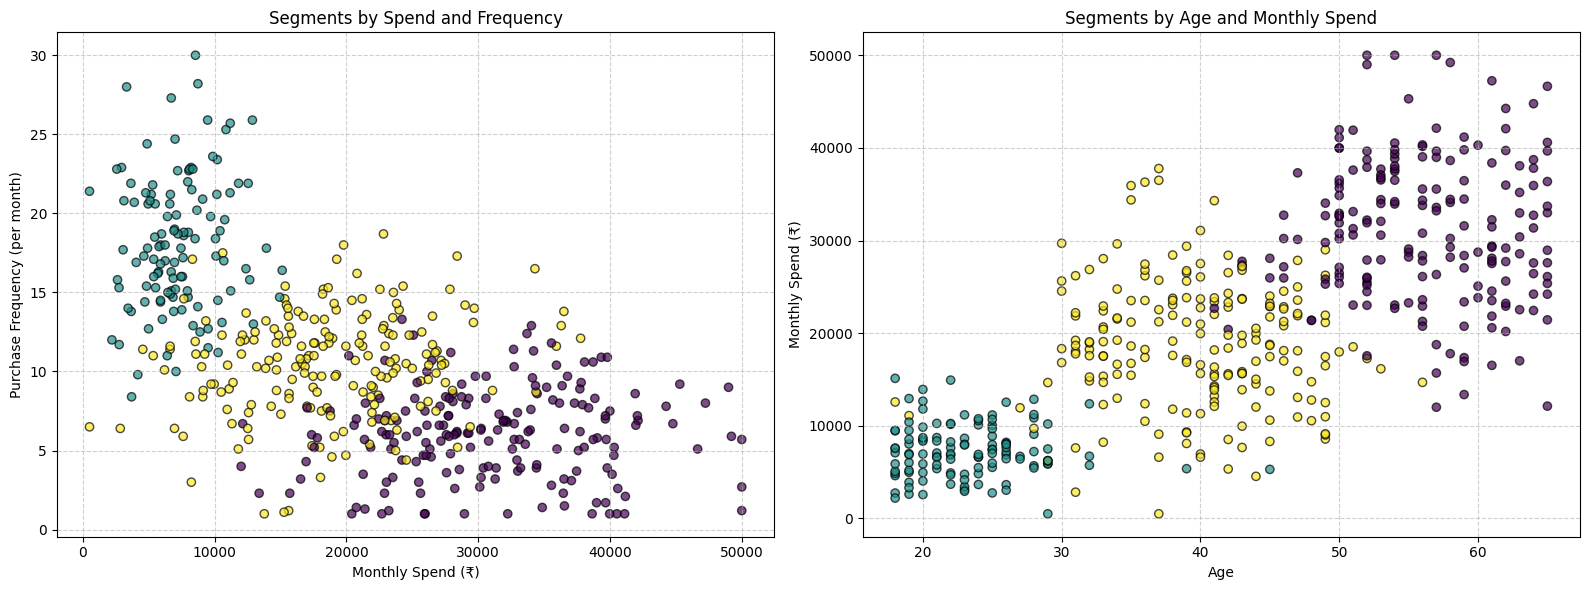

In [26]:
plt.figure(figsize=(16, 6))

# Visualization 1: Monthly Spend vs. Purchase Frequency
plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'], c=df_cleaned['cluster'], cmap='viridis', edgecolors='k', alpha=0.7)
plt.title('Segments by Spend and Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency (per month)')
plt.grid(True, linestyle='--', alpha=0.6)

# Visualization 2: Age vs. Monthly Spend
plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'], c=df_cleaned['cluster'], cmap='viridis', edgecolors='k', alpha=0.7)
plt.title('Segments by Age and Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Visualizing the Customer Segments

Finally, we visualize our clusters using scatter plots. These plots help us confirm the distinct separation between the identified customer groups.

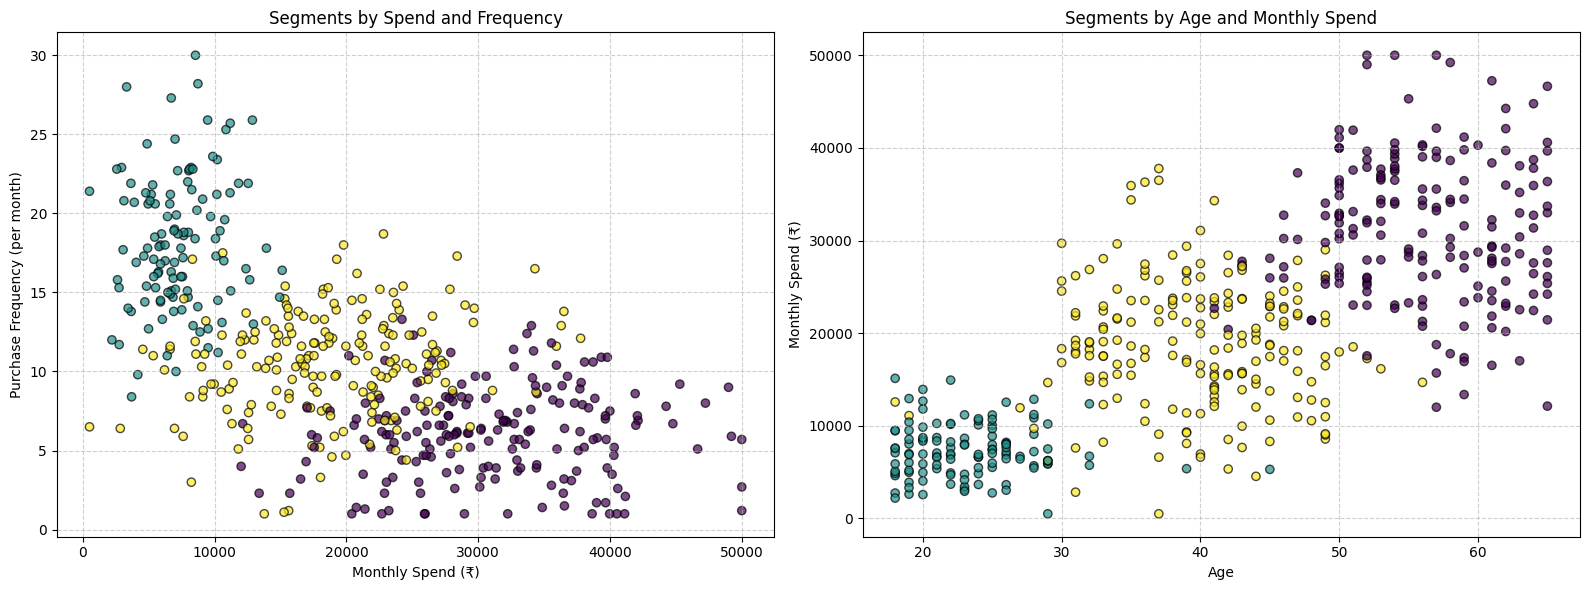

In [25]:
plt.figure(figsize=(16, 6))

# Visualization 1: Monthly Spend vs. Purchase Frequency
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'], c=df_cleaned['cluster'], cmap='viridis', edgecolors='k', alpha=0.7)
plt.title('Segments by Spend and Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency (per month)')
plt.grid(True, linestyle='--', alpha=0.6)

# Visualization 2: Age vs. Monthly Spend
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'], c=df_cleaned['cluster'], cmap='viridis', edgecolors='k', alpha=0.7)
plt.title('Segments by Age and Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Visualizing Clusters

We will visualize the clusters using scatter plots to see how the segments are distributed across our key features.

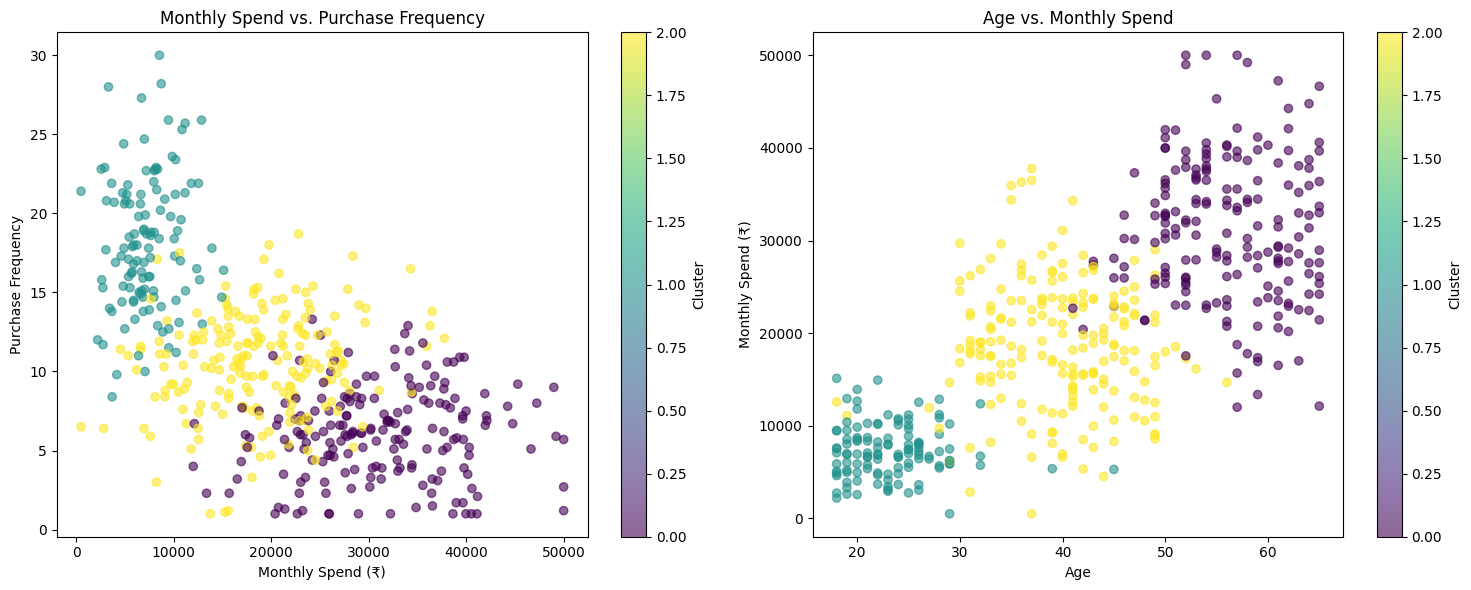

In [24]:
plt.figure(figsize=(15, 6))

# Spend vs Frequency
plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'], c=df_cleaned['cluster'], cmap='viridis', alpha=0.6)
plt.title('Monthly Spend vs. Purchase Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency')
plt.colorbar(label='Cluster')

# Age vs Spend
plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'], c=df_cleaned['cluster'], cmap='viridis', alpha=0.6)
plt.title('Age vs. Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

## Data Cleaning: Handling Duplicates and Missing Values

In [5]:
# Identify and remove duplicate rows
initial_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df_cleaned.shape[0]
print(f"Number of duplicate rows removed: {duplicate_rows_removed}")
print("DataFrame after removing duplicates:")
print(df_cleaned.head())
print(f"New DataFrame shape: {df_cleaned.shape}")

Number of duplicate rows removed: 0
DataFrame after removing duplicates:
   age  monthly_spend  purchase_frequency
0   56       28380.34                 6.2
1   46       24530.14                10.5
2   32        6718.36                15.1
3   60       25078.93                12.3
4   25       10060.55                18.4
New DataFrame shape: (500, 3)


In [6]:
# Handle missing values
# Check for missing values
print("\nMissing values before handling:")
print(df_cleaned.isnull().sum())

# Given a small number of NaNs (4 out of 500 entries) in both 'monthly_spend' and 'purchase_frequency',
# dropping these rows is a reasonable approach to avoid imputation bias.
df_cleaned.dropna(inplace=True)

print("\nMissing values after handling:")
print(df_cleaned.isnull().sum())
print("DataFrame after dropping rows with missing values:")
print(df_cleaned.head())
print(f"New DataFrame shape: {df_cleaned.shape}")


Missing values before handling:
age                   0
monthly_spend         0
purchase_frequency    0
dtype: int64

Missing values after handling:
age                   0
monthly_spend         0
purchase_frequency    0
dtype: int64
DataFrame after dropping rows with missing values:
   age  monthly_spend  purchase_frequency
0   56       28380.34                 6.2
1   46       24530.14                10.5
2   32        6718.36                15.1
3   60       25078.93                12.3
4   25       10060.55                18.4
New DataFrame shape: (500, 3)


## Data Cleaning: Handling Outliers

In [7]:
# Identify and handle extreme outliers in 'monthly_spend'
# Given the identified outliers are ₹95,000 and ₹88,000, we will investigate and cap them if necessary.
# First, let's look at the distribution and actual values.

print("\nDescriptive statistics for 'monthly_spend' before outlier handling:")
print(df_cleaned['monthly_spend'].describe())

# Given the values 95,000 and 88,000 are explicitly mentioned as unrealistic outliers,
# we can cap them to a more reasonable upper bound based on the data's general distribution or a domain-specific threshold.
# For demonstration, let's cap values above a certain percentile (e.g., 99th percentile) or a specific value.
# Let's check the current maximum to decide on a capping strategy.

upper_bound = df_cleaned['monthly_spend'].quantile(0.99) # Using 99th percentile as a dynamic upper bound
print(f"\n99th percentile for monthly_spend: {upper_bound}")

# Assuming the 95000 and 88000 are indeed outliers and should be capped or removed.
# For this task, let's cap them to a value slightly above the 95th percentile, or a fixed reasonable value.
# Let's cap anything above 40,000 as it seems significantly higher than the 75th percentile (around 25,000 from head and 30,000 from describe).
# The problem statement states 95,000 and 88,000 are unrealistic, so we can set a more sensible cap.
# Let's cap values greater than 40,000.

outlier_count = df_cleaned[df_cleaned['monthly_spend'] > 40000].shape[0]
print(f"Number of monthly_spend values above 40,000 before capping: {outlier_count}")

df_cleaned['monthly_spend'] = df_cleaned['monthly_spend'].apply(lambda x: 40000 if x > 40000 else x)

print("\nDescriptive statistics for 'monthly_spend' after outlier handling:")
print(df_cleaned['monthly_spend'].describe())
print("DataFrame after handling outliers in 'monthly_spend':")
print(df_cleaned.head())
print(f"New DataFrame shape: {df_cleaned.shape}")


Descriptive statistics for 'monthly_spend' before outlier handling:
count      500.000000
mean     20711.163140
std      11282.516511
min        500.000000
25%      10554.097500
50%      20779.745000
75%      28378.007500
max      50000.000000
Name: monthly_spend, dtype: float64

99th percentile for monthly_spend: 47259.44719999998
Number of monthly_spend values above 40,000 before capping: 21

Descriptive statistics for 'monthly_spend' after outlier handling:
count      500.00000
mean     20533.80290
std      10913.41477
min        500.00000
25%      10554.09750
50%      20779.74500
75%      28378.00750
max      40000.00000
Name: monthly_spend, dtype: float64
DataFrame after handling outliers in 'monthly_spend':
   age  monthly_spend  purchase_frequency
0   56       28380.34                 6.2
1   46       24530.14                10.5
2   32        6718.36                15.1
3   60       25078.93                12.3
4   25       10060.55                18.4
New DataFrame shape: (50

## Determining Optimal Number of Clusters (Elbow Method)

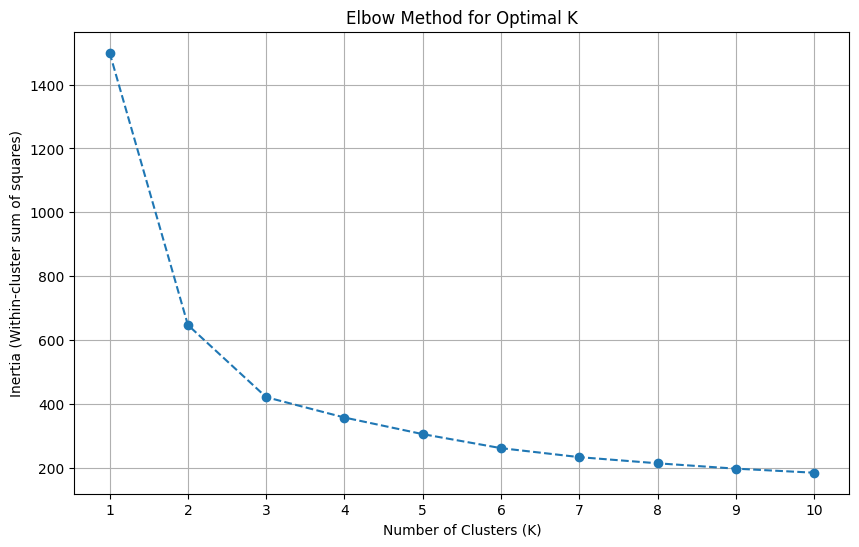

In [9]:
# Calculate Inertia for different numbers of clusters
inertia = []
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## K-Means Clustering and Cluster Assignment

In [10]:
# Apply K-Means with the chosen number of clusters (e.g., k=3 based on Elbow Method)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster labels to the original (cleaned) DataFrame
df_cleaned['cluster'] = kmeans.labels_

print(f"DataFrame with {k} clusters assigned (first 5 rows):")
print(df_cleaned.head())
print(f"\nCluster distribution:\n{df_cleaned['cluster'].value_counts()}")

DataFrame with 3 clusters assigned (first 5 rows):
   age  monthly_spend  purchase_frequency  cluster
0   56       28380.34                 6.2        0
1   46       24530.14                10.5        1
2   32        6718.36                15.1        2
3   60       25078.93                12.3        0
4   25       10060.55                18.4        2

Cluster distribution:
cluster
1    194
0    189
2    117
Name: count, dtype: int64


## Analyzing Cluster Characteristics

In [11]:
# Analyze the characteristics of each cluster
cluster_centers = df_cleaned.groupby('cluster').mean()
print("\nCluster Characteristics (Mean values for each feature by cluster):\n")
print(cluster_centers)

# Optional: Add unscaled cluster centers for better interpretability
# To get unscaled values, we can inverse transform the cluster centers from the scaled data
# However, it's often more intuitive to look at the means of the original features within each cluster
# as done above with df_cleaned.groupby('cluster').mean()


Cluster Characteristics (Mean values for each feature by cluster):

               age  monthly_spend  purchase_frequency
cluster                                              
0        56.010582   30593.285926            6.074603
1        39.561856   18724.126031           10.497423
2        23.324786    7284.529573           18.119658


## Visualizing Clusters

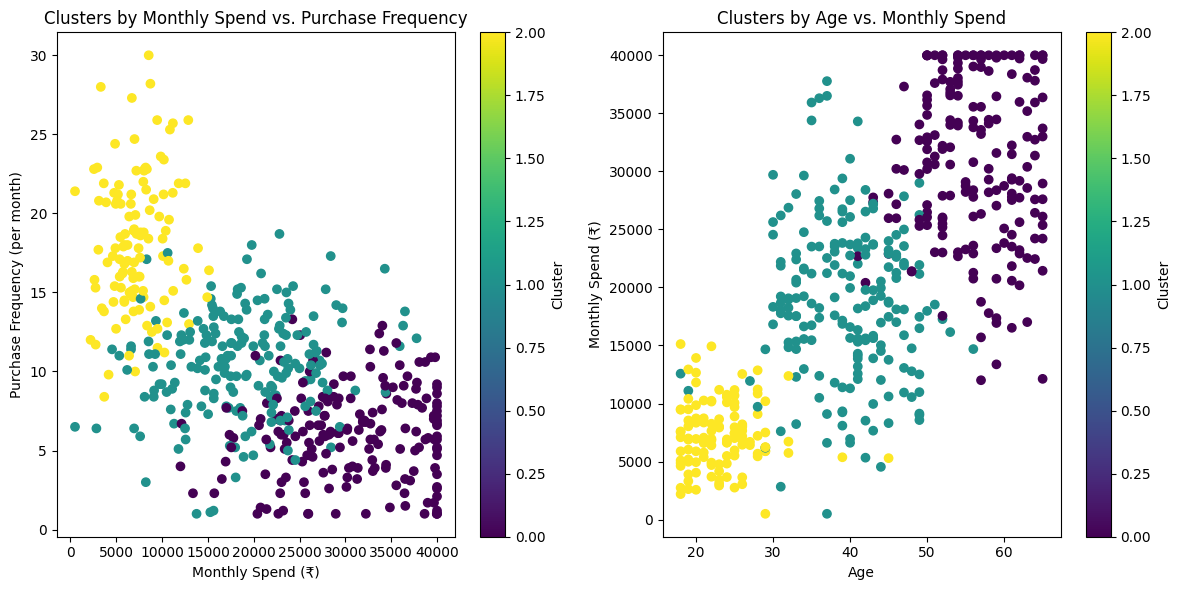

In [12]:
# Visualize the clusters (e.g., using scatter plots of selected features)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(df_cleaned['monthly_spend'], df_cleaned['purchase_frequency'], c=df_cleaned['cluster'], cmap='viridis')
plt.title('Clusters by Monthly Spend vs. Purchase Frequency')
plt.xlabel('Monthly Spend (₹)')
plt.ylabel('Purchase Frequency (per month)')
plt.colorbar(label='Cluster')

plt.subplot(1, 2, 2)
plt.scatter(df_cleaned['age'], df_cleaned['monthly_spend'], c=df_cleaned['cluster'], cmap='viridis')
plt.title('Clusters by Age vs. Monthly Spend')
plt.xlabel('Age')
plt.ylabel('Monthly Spend (₹)')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

## Feature Scaling

In [8]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned), columns=df_cleaned.columns)

print("Scaled DataFrame (first 5 rows):")
print(df_scaled.head())
print("\nDescriptive statistics for scaled features:")
print(df_scaled.describe())

Scaled DataFrame (first 5 rows):
        age  monthly_spend  purchase_frequency
0  1.016915       0.719701           -0.775465
1  0.291583       0.366552           -0.019205
2 -0.723881      -1.267182            0.789816
3  1.307048       0.416889            0.297368
4 -1.231614      -0.960629            1.370201

Descriptive statistics for scaled features:
                age  monthly_spend  purchase_frequency
count  5.000000e+02   5.000000e+02        5.000000e+02
mean   2.415845e-16   9.237056e-17       -2.344791e-16
std    1.001002e+00   1.001002e+00        1.001002e+00
min   -1.739346e+00  -1.837543e+00       -1.690011e+00
25%   -7.964145e-01  -9.153597e-01       -7.402899e-01
50%    7.398386e-02   2.255833e-02       -1.247300e-01
75%    7.993158e-01   7.194870e-01        5.831639e-01
max    1.669714e+00   1.785481e+00        3.410343e+00
